In [1]:
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import imageio
import cv2
import dill
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import seaborn as sns
from copy import deepcopy
from matplotlib.widgets import Slider

from four_room.env import FourRoomsEnv
from four_room.constants import train_config, size
from four_room.wrappers import gym_wrapper
from four_room.shortest_path import find_all_shortest_paths
from four_room.utils import obs_to_state

from utils.q_values import compute_mc

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

%load_ext autoreload
%autoreload 2

(<matplotlib.image.AxesImage at 0x242dfcbeb90>,
 array([list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 0), (13, 7, 3), (13, 6, 3), (13, 5, 3), (13, 4, 3), (13, 3, 3), (13, 3, 2), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (4, 3, 2), (4, 3, 1), (4, 4, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (np.int64(4), np.int64(8), 1)]),
        list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 2), (13, 7, 3), (13, 6, 3), (13, 5, 3), (13, 4, 3), (13, 3, 3), (13, 3, 2), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (4, 3, 2), (4, 3, 1), (4, 4, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (np.int64(4), np.int64(8), 1)]),
        list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 2), (12, 7, 2), (12, 7, 3), (12, 6, 3), (12, 5, 3), (12, 4, 3), (12, 3, 3), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (

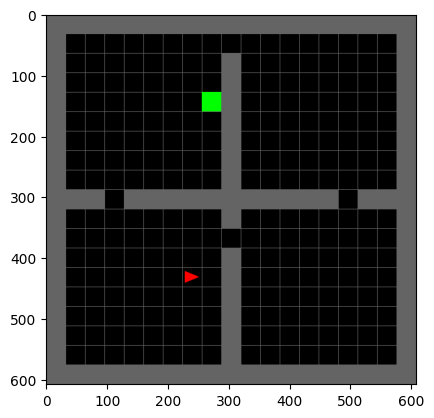

In [3]:
env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        

env.get_wrapper_attr('set_context')(199)
obs, _ = env.reset()
state = obs_to_state(obs)
paths = find_all_shortest_paths(state[:2], state[2], state[3:5], state[5:], size)


plt.imshow(cv2.transpose(env.render())), paths, env.get_wrapper_attr('context')

In [ ]:

def plot_map(file_name: str, env_ids: int):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for idx, ax in enumerate(axes.flat):
        matrix = results['heatmap'][env_ids[idx]]
        colors = np.full((19, 19), np.nan, dtype=float)

        colors[0, :] = 0
        colors[-1, :] = 0
        colors[:, 0] = 0
        colors[:, -1] = 0

        colors[9, :] = 0
        colors[:, 9] = 0
        
        env.get_wrapper_attr('set_context')(env_ids[idx])
        _, _ = env.reset()
        start_pos, doors_pos, goal_pos = env.get_wrapper_attr('context_info')(env_ids[idx])
        
        room_w = 19//2
        room_h = 19//2
        
        highlight_cells = []
        for j in range(0, 2):
            for i in range(0, 2):
                xL = i * room_w
                yT = j * room_h
                xR = xL + room_w
                yB = yT + room_h

                if i + 1 < 2:
                    pos = (xR, yT + 1 + doors_pos[j])
                    highlight_cells.append(pos)

                if j + 1 < 2:
                    pos = (xL + 1 + doors_pos[2 + i], yB)
                    highlight_cells.append(pos)
        
        colors[start_pos[0], start_pos[1]] = 1
        colors[goal_pos[0], goal_pos[1]] = 2

        for r, c in highlight_cells:
            colors[r, c] = np.nan

        matrix_data = deepcopy(matrix).astype(str)
        for r in range(matrix_data.shape[0]):
            for c in range(matrix_data.shape[1]):
                matrix_data[r, c] = str(int(matrix[r, c]))
                
        matrix_data[start_pos[0], start_pos[1]] = 'Start'
        matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'
        
        sns.heatmap(matrix, cmap='magma', annot=matrix_data, cbar_kws={'label': 'Number of switches'}, ax=ax, fmt='')

        overlay_cmap = sns.color_palette(["grey", "red", "lime"])
        sns.heatmap(colors, cmap=overlay_cmap, mask=np.isnan(colors), cbar=False, alpha=0.6, ax=ax)
        ax.set_title(f"H0eatmap Env {env_ids[idx]}")

    plt.tight_layout()
    plt.show()

    env.close()

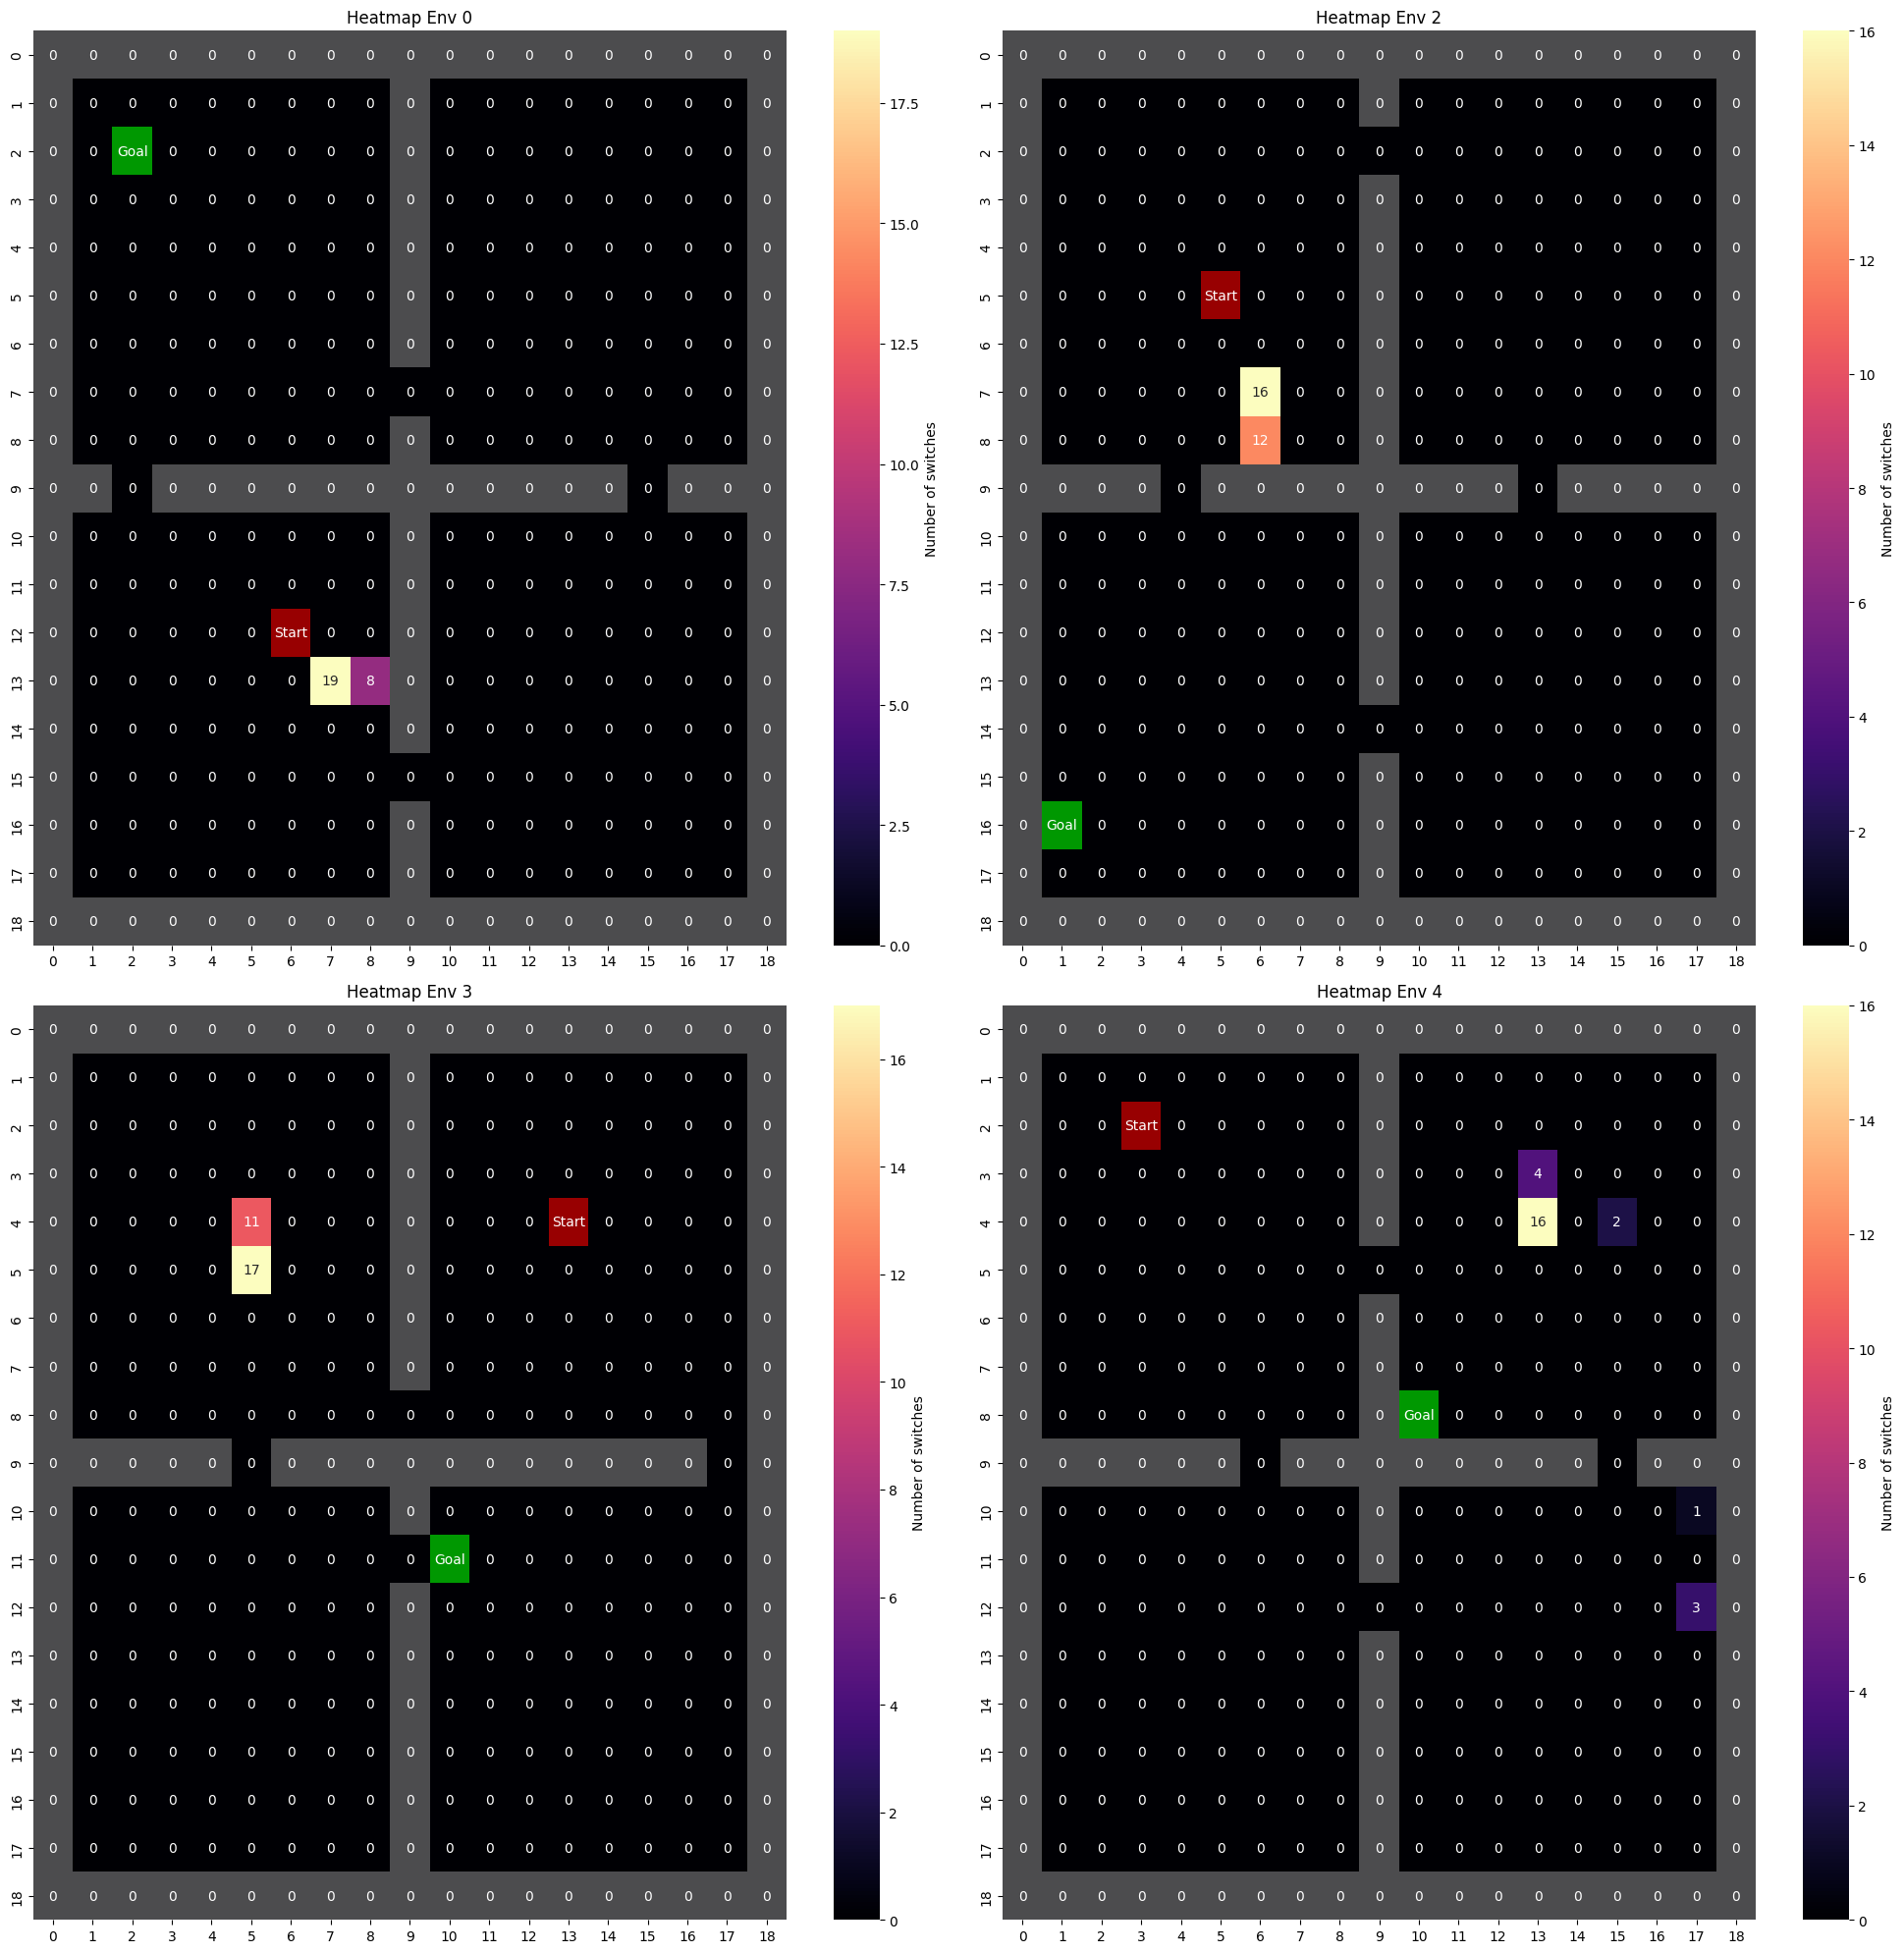

In [5]:
plot_map('basic_count_fixed_seed_0_100000', [0, 2, 3, 4])

In [3]:
def plot_env_heatmap(results, context_info: tuple, label: str, title: str, ax=None, annot: bool = True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    matrix = results
    colors = np.full((19, 19), np.nan, dtype=float)

    colors[0, :] = 0
    colors[-1, :] = 0
    colors[:, 0] = 0
    colors[:, -1] = 0
    colors[9, :] = 0
    colors[:, 9] = 0

    start_pos, doors_pos, goal_pos = context_info

    room_w = 19 // 2
    room_h = 19 // 2

    highlight_cells = []
    for j in range(2):
        for i in range(2):
            xL = i * room_w
            yT = j * room_h
            xR = xL + room_w
            yB = yT + room_h

            if i + 1 < 2:
                pos = (xR, yT + 1 + doors_pos[j])
                highlight_cells.append(pos)

            if j + 1 < 2:
                pos = (xL + 1 + doors_pos[2 + i], yB)
                highlight_cells.append(pos)

    colors[start_pos[0], start_pos[1]] = 1
    colors[goal_pos[0], goal_pos[1]] = 2

    for r, c in highlight_cells:
        colors[r, c] = np.nan

    matrix_data = deepcopy(matrix).astype(str)
    for r in range(matrix_data.shape[0]):
        for c in range(matrix_data.shape[1]):
            matrix_data[r, c] = str(int(matrix[r, c]))

    matrix_data[start_pos[0], start_pos[1]] = 'Start'
    matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'

    sns.heatmap(
        matrix,
        cmap='magma',
        annot=matrix_data if annot else False,
        cbar_kws={'label': label},
        ax=ax,
        xticklabels=False, 
        yticklabels=False,
        fmt=''
    )

    overlay_cmap = sns.color_palette(["grey", "red", "lime"])
    sns.heatmap(
        colors,
        cmap=overlay_cmap,
        mask=np.isnan(colors),
        cbar=False,
        alpha=0.6,
        xticklabels=False, 
        yticklabels=False,
        ax=ax
    )

    ax.set_title(f"{title}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return ax

def find_states(history: list, timestep: int, capacity: int):
    states = []
    begin = timestep - capacity if timestep > capacity else 0
    
    for i in range(len(history)):
        step, context, x, y = history[i]    
        if begin <= step-1 <= timestep:
            states.append((context, x, y))
    
    return states

In [10]:
def plot_timestep(file_name: str, timestep: int, annot_expl: bool = True, remove_dir: bool = True):
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)
        
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )  
    
    # get switches
    switch_history = results['switch_states']
    buffer_switch_counts = np.zeros_like(results['heatmap'])
    buffer_moving = results['counter_moving']
    buffer_full = results['counter_full']
    full_switches = results['heatmap']
    explored_states = results['explore_heatmap']
    aux_states = results['aux_heatmap']
    
    relevant_switches = find_states(switch_history, timestep, buffer_moving.capacity)
    for switch in relevant_switches:
        buffer_switch_counts[*switch] += 1
    
    relevant_buffer_states = find_states(buffer_moving.all_states, timestep, buffer_moving.capacity)
    relevant_buffer = np.zeros_like(aux_states)
    for state in relevant_buffer_states:
        relevant_buffer[*state] += 1
        
    context = results['context_history'][timestep]
    context_info = env.get_wrapper_attr('context_info')(context)
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    # moving switch count
    plot_env_heatmap(buffer_switch_counts[context], context_info,
                     'Switch Counts', f'Switches Heatmap for context {context}', axes[0, 0]) 
    # moving buffer count
    plot_env_heatmap(relevant_buffer[context], context_info, 
                     'Buffer Counts', f'Buffer Heatmap for context {context}', axes[0, 1]) 
    # full switches
    plot_env_heatmap(full_switches[context], context_info, 
                     'Switch Counts (full)', f'Switches Heatmap (full) for context {context}', axes[1, 0]) 
    # full buffer
    plot_env_heatmap(buffer_full.counts_matrix[context], context_info, 
                     'Buffer Counts (full)', f'Buffer Heatmap (full) for context {context}', axes[1, 1])
    # explored states 
    plot_env_heatmap(explored_states[context], context_info, 
                     'Explore Counts', f'Explored States (full) for context {context}', axes[2, 0], annot=annot_expl) 
    # aux selected states
    plot_env_heatmap(aux_states[context], context_info, 
                     'Aux Counts', f'Aux Selected Heatmap (full) for context {context}', axes[2, 1], annot=annot_expl)
    
    env.close()
    
    return (fig, axes)

In [174]:
env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )

In [176]:
print(env.get_wrapper_attr('context'))

0


0
0
((12, 6), (1, 5, 6, 5), (2, 2))


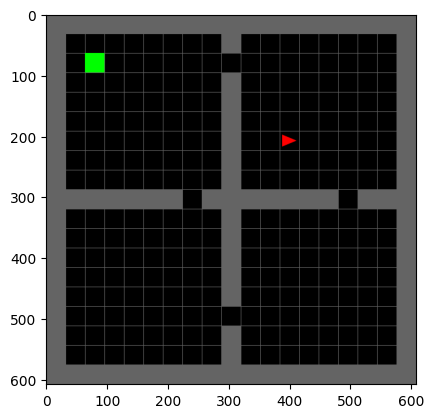

In [168]:
env.get_wrapper_attr('set_context')(0)
print(env.get_wrapper_attr('context'))
print(env.unwrapped.context)
print(env.get_wrapper_attr('context_info')(0))
env.reset()
plt.imshow(env.unwrapped.render());

In [10]:
with open(f'results/dqn_exps/dqn_count_test_seed_0_1000.pl', 'rb') as file:
    results = dill.load(file)

In [ ]:
import plotly.graph_objects as go

def plot_interactive_timesteps(file_name: str, timesteps: list[int], annot_expl: bool = True):
    figs_axes = [plot_timestep(file_name, t, annot_expl=annot_expl) for t in timesteps]
    figs = [f for f, _ in figs_axes]
    figs[0].canvas.draw_idle()
    
    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(ax_slider, 'Timestep', 0, len(figs) - 1, valinit=0, valstep=1)
    
    def update(val):
        idx = int(slider.val)
        figs[idx].canvas.draw_idle()
        
    slider.on_changed(update)
    plt.show()

In [ ]:
plot_interactive_timesteps('basic_count_fixed_moving_seed_0_100000', [10, 11, 12, 13])

Generating 4 matplotlib figures...
  Processing timestep 10 (1/4)
  Processing timestep 11 (2/4)
  Processing timestep 12 (3/4)
  Processing timestep 13 (4/4)
Done! Use the slider to navigate between timesteps.


In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rms(data_tuples, titles=None, figsize=(16, 5), style='ggplot',
             low_q=5, high_q=95, pad=0.1):
    plt.style.use(style)
    n = len(data_tuples)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for i, (means, stds) in enumerate(data_tuples):
        m = np.asarray(means, float)
        s = np.asarray(stds, float)
        x = np.arange(len(m))

        lower = m - s
        upper = m + s

        ax = axes[i]
        ax.plot(x, m)
        ax.fill_between(x, lower, upper, alpha=0.25)

        # robust y-limits: ignore extremes
        all_vals = np.concatenate([lower, upper])
        lo = np.nanpercentile(all_vals, low_q)
        hi = np.nanpercentile(all_vals, high_q)

        # add padding
        yr = hi - lo
        if yr == 0:
            yr = 1.0
        lo -= pad * yr
        hi += pad * yr
        ax.set_ylim(lo, hi)

        if titles:
            ax.set_title(titles[i])

        ax.grid(True)

    plt.tight_layout()
    return fig, axes


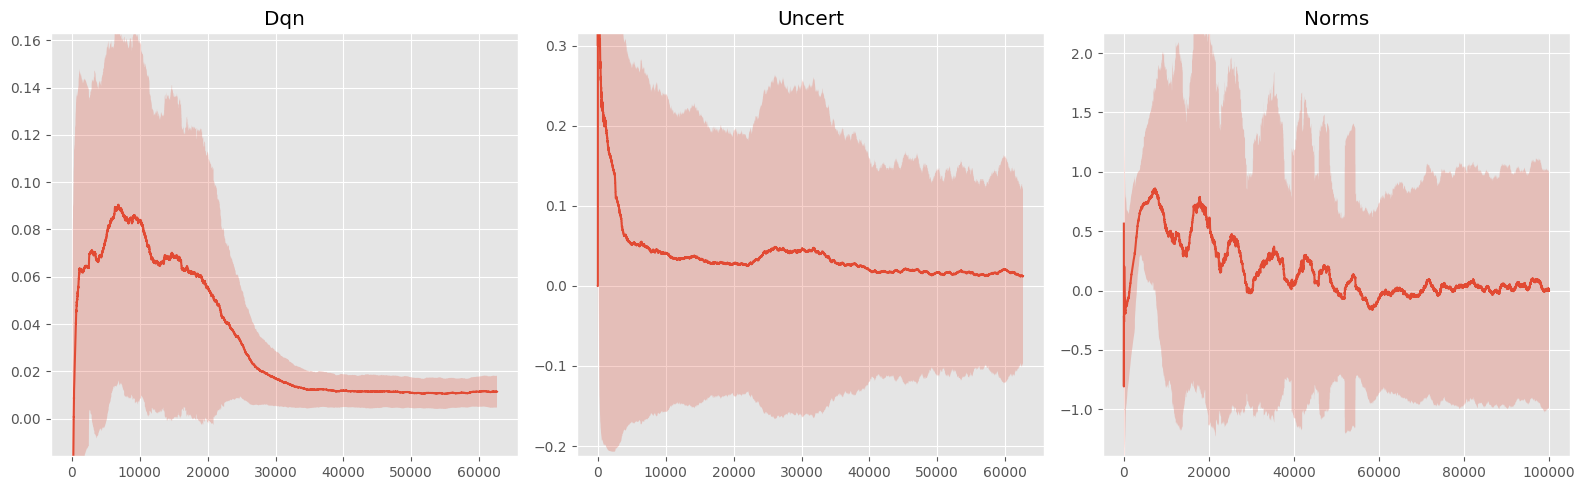

In [ ]:
with open(f'results/dqn_exps/dqn_count_test_seed_0_100000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

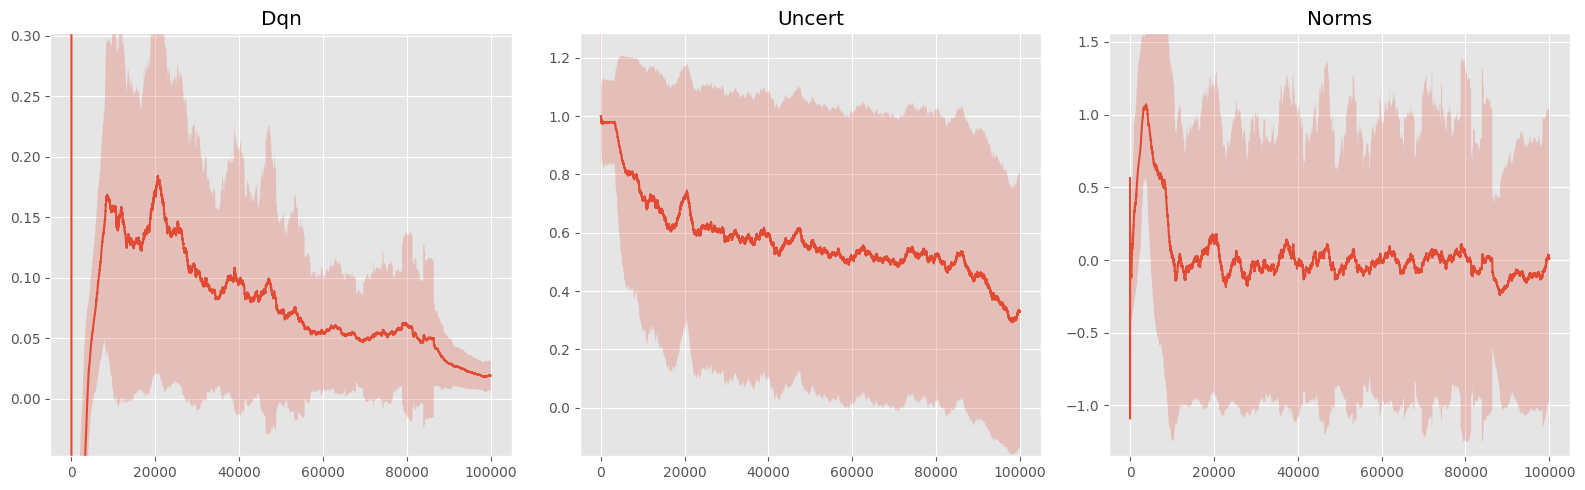

In [24]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_seed_0_100000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

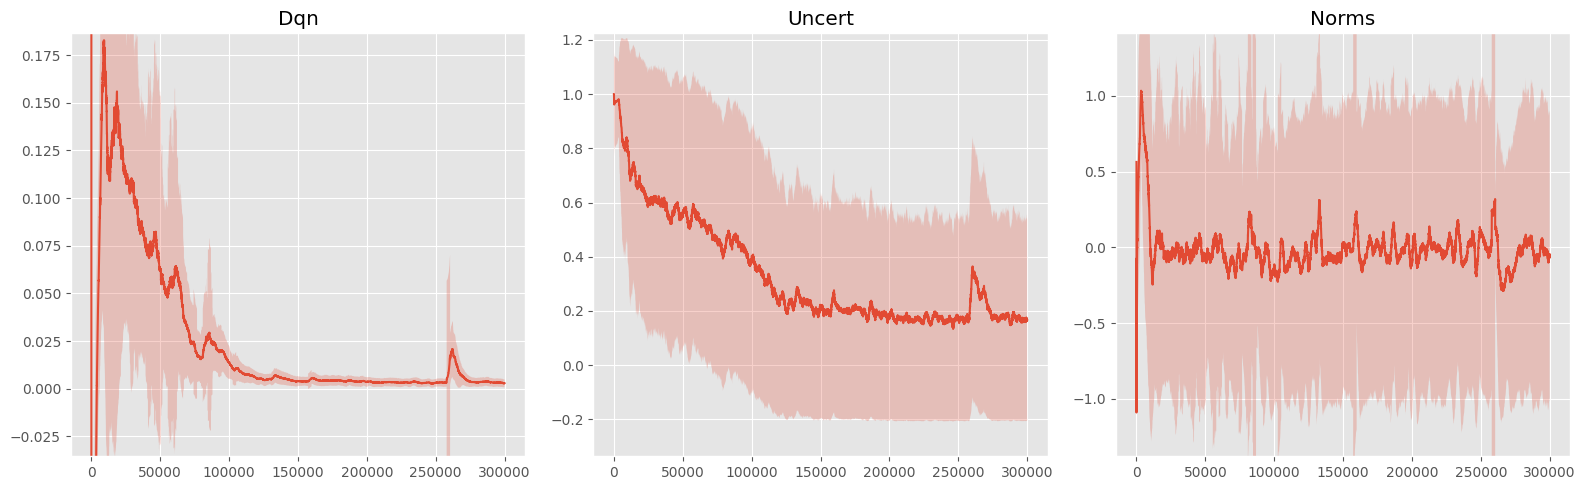

In [37]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

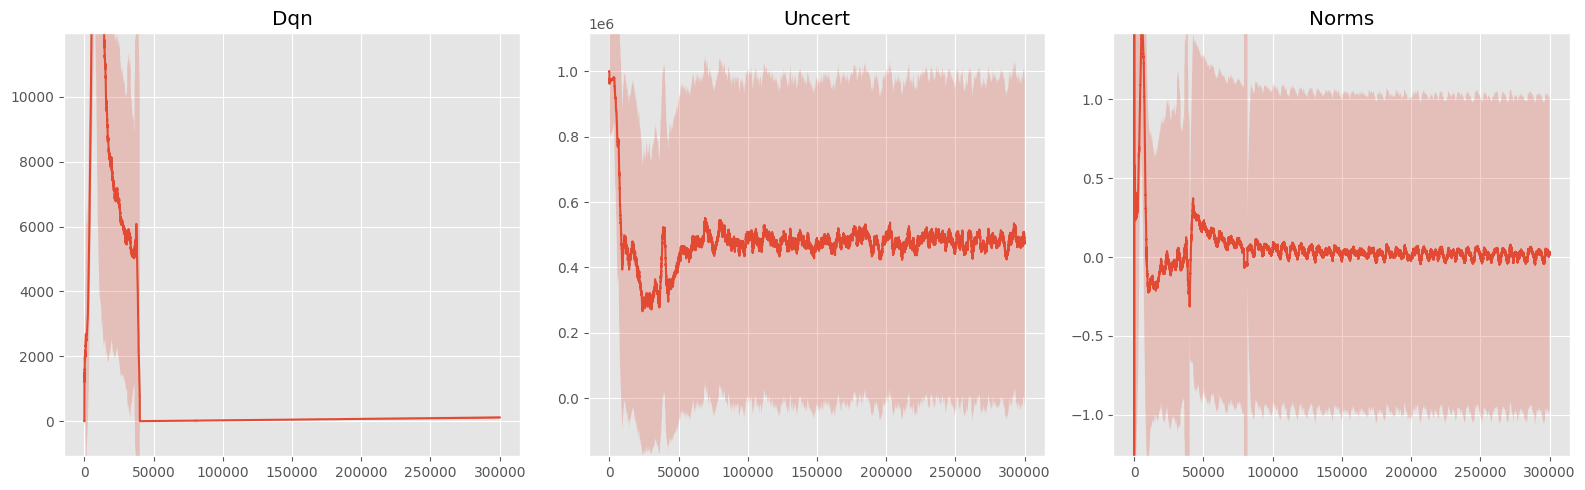

In [28]:
with open(f'results/dqn_exps/dqn_count_no_ones_new_rms_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

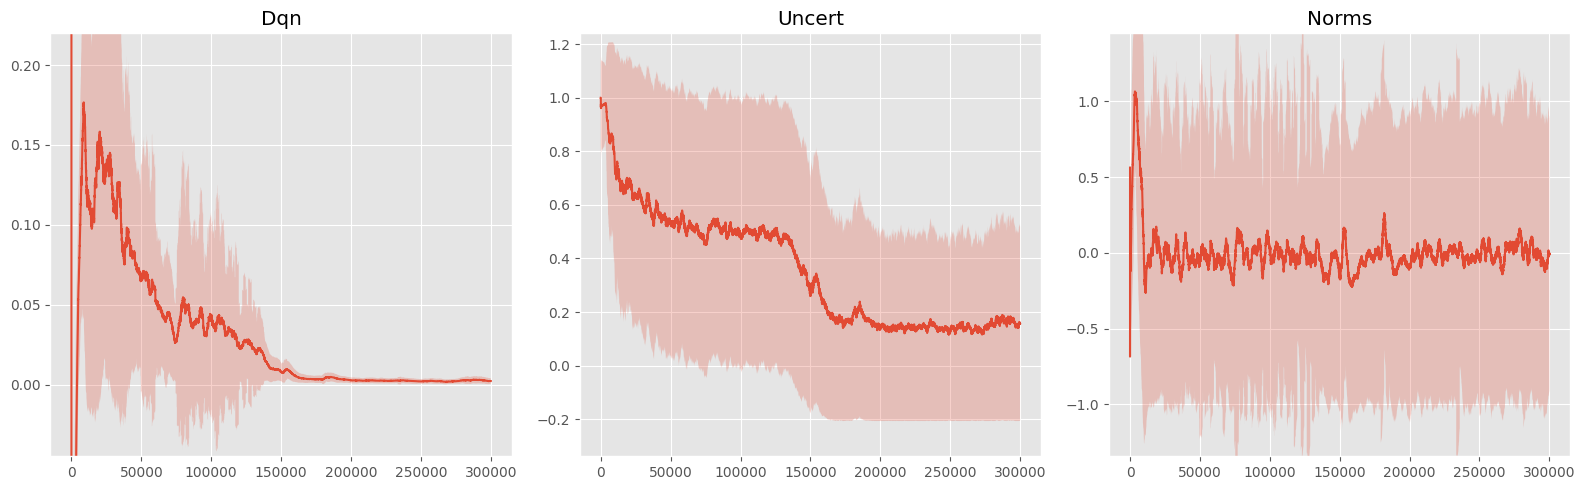

In [41]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_low_lr_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

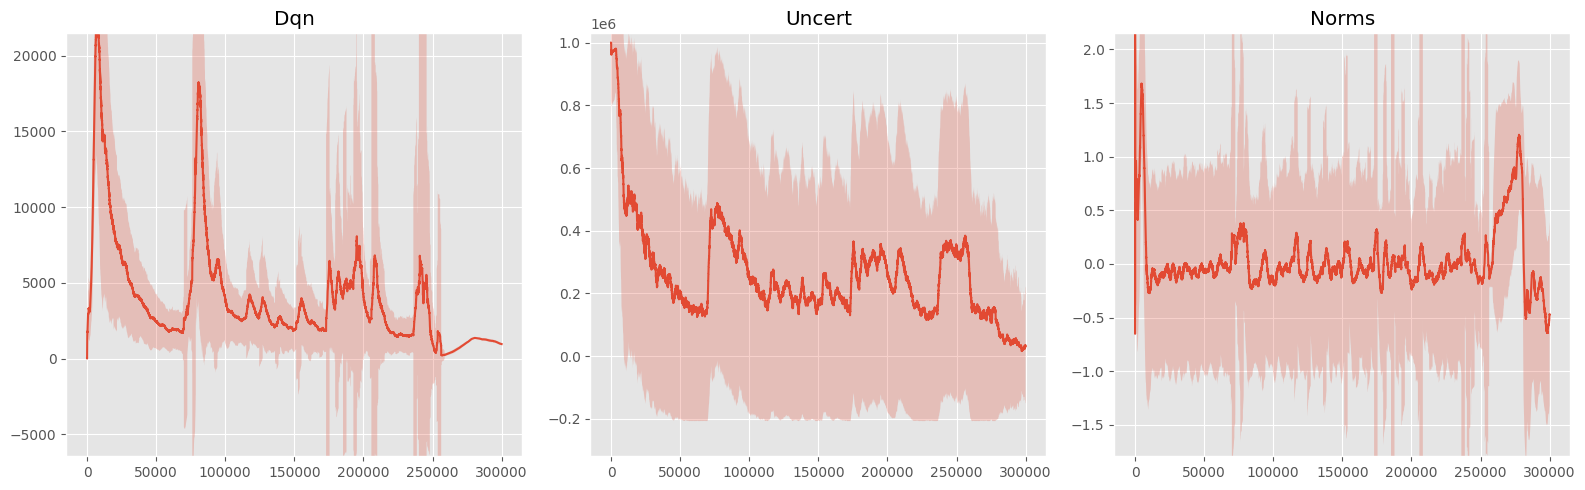

In [45]:
with open(f'results/dqn_exps/dqn_count_no_ones_new_rms_low_lr_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

In [24]:
def make_table_opt(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Ones", str),
        ("Alt", str),
        ("Window", int),
        ("Uniquness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for one in hyperparameters[1]:
            for alt in hyperparameters[2]:
                for window in hyperparameters[3]:
                    clean_alpha = str(alpha).replace(".", "")
                    file_name = f'opt_count_alpha{clean_alpha}_{one}_{alt}_window{window}_seed_0_300000.pl'
                    with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                        temp = dill.load(file)
                    
                    uniqueness = temp['uniqueness'][-1]
                    size = temp['counter_moving'].size

                    data_objs.append(
                        Config(alpha, one, alt, window, uniqueness, size, file_name)
                    ) 
            
    return pd.DataFrame(data_objs)

In [25]:
pd.set_option('display.max_colwidth', None)

make_table_opt(
    ([2.0, 3.0, 5.0], 
     ['none', 'return_ones'],
     ['none', 'alt'], 
     [500, 3500, 5000])
)

,Alpha,Ones,Alt,Window,Uniquness,Size,FileName
0,2.0,none,none,500,0.276410,100000,opt_count_alpha20_none_none_window500_seed_0_300000.pl
1,2.0,none,none,3500,0.276060,100000,opt_count_alpha20_none_none_window3500_seed_0_300000.pl
2,2.0,none,none,5000,0.275470,100000,opt_count_alpha20_none_none_window5000_seed_0_300000.pl
3,2.0,none,alt,500,0.081610,100000,opt_count_alpha20_none_alt_window500_seed_0_300000.pl
4,2.0,none,alt,3500,0.112262,74985,opt_count_alpha20_none_alt_window3500_seed_0_300000.pl
5,2.0,none,alt,5000,0.126601,67314,opt_count_alpha20_none_alt_window5000_seed_0_300000.pl
6,2.0,return_ones,none,500,0.276410,100000,opt_count_alpha20_return_ones_none_window500_seed_0_300000.pl
7,2.0,return_ones,none,3500,0.276060,100000,opt_count_alpha20_return_ones_none_window3500_seed_0_300000.pl
8,2.0,return_ones,none,5000,0.275470,100000,opt_count_alpha20_return_ones_none_window5000_seed_0_300000.pl
9,2.0,return_ones,alt,500,0.080500,100000,opt_count_alpha20_return_ones_alt_window500_seed_0_300000.pl


In [26]:
def make_table_count(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Ones", str),
        ("LR", int),
        ("Uniqueness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for one in hyperparameters[1]:
            for lr in hyperparameters[2]:
                clean_alpha = str(alpha).replace(".", "")
                clean_lr = str(lr).replace(".", "")
                file_name = f'dqn_count_alpha{clean_alpha}_{one}_lr{clean_lr}_seed_0_300000.pl'
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                
                uniqueness = temp['uniqueness'][-1]
                size = temp['counter_moving'].size

                data_objs.append(
                    Config(alpha, one, lr, uniqueness, size, file_name)
                ) 
            
    return pd.DataFrame(data_objs)

In [27]:
make_table_count((
    [2.0, 3.0, 5.0], 
     ['none', 'return_ones'], 
     [0.01, 0.001, 0.0001, '0.00001']
))

,Alpha,Ones,LR,Uniqueness,Size,FileName
0,2.0,none,0.01,0.435442,23080,dqn_count_alpha20_none_lr001_seed_0_300000.pl
1,2.0,none,0.001,0.408917,22496,dqn_count_alpha20_none_lr0001_seed_0_300000.pl
2,2.0,none,0.0001,0.280322,43739,dqn_count_alpha20_none_lr00001_seed_0_300000.pl
3,2.0,none,0.00001,0.237826,59922,dqn_count_alpha20_none_lr000001_seed_0_300000.pl
4,2.0,return_ones,0.01,0.266736,52029,dqn_count_alpha20_return_ones_lr001_seed_0_300000.pl
5,2.0,return_ones,0.001,0.266191,52004,dqn_count_alpha20_return_ones_lr0001_seed_0_300000.pl
6,2.0,return_ones,0.0001,0.317388,38026,dqn_count_alpha20_return_ones_lr00001_seed_0_300000.pl
7,2.0,return_ones,0.00001,0.440923,36943,dqn_count_alpha20_return_ones_lr000001_seed_0_300000.pl
8,3.0,none,0.01,0.649940,10901,dqn_count_alpha30_none_lr001_seed_0_300000.pl
9,3.0,none,0.001,0.885060,4150,dqn_count_alpha30_none_lr0001_seed_0_300000.pl


In [18]:
import networkx as nx
from four_room.shortest_path import create_maze_graph
import random


from dqn.counter import MovingCountBasedUncertainty
from utils.exploration import aux_pos_multiple


env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )

np.random.seed(0)
random.seed(0)

obs, _ = env.reset()
state = obs_to_state(obs)

counter = MovingCountBasedUncertainty(return_ones=False, capacity=5000, dir=False)
opt = [(12, 6, 0), (12, 6, 3), (12, 5, 3), (12, 5, 0), (13, 5, 0), (14, 5, 0), (15, 5, 0), (15, 5, 1), (15, 5, 2)]
opt2 = [(12, 6), (12, 6), (12, 5), (12, 5), (13, 5), (14, 5), (15, 5), (15, 5), (15, 5)]
graph = create_maze_graph(state[5:], size)
nodes = list(graph.nodes)
k = np.random.randint(low=0, high=len(nodes))
aux_pos = (1, 1, 1)

for p in nx.all_simple_paths(graph, source=state[:3], target=aux_pos):
    path = p
    break

for node in nodes:
    if tuple(node[:2]) in opt2:
        continue
    counter.counts[0, *node[:2]] = 5

mat = np.abs(np.random.normal(size=(19, 19)))

for edge in graph.edges:
    graph[edge[0]][edge[1]]['weight'] = mat[*edge[1][:2]]

# unc = 0
# for node in nx.dijkstra_path(graph, source=state[:3], target=aux_pos):
#     unc += counter.counts[0, *node[:2]]

def heuristic(node1, node2):
    return counter.counts[0, *node2[:2]]

In [19]:
path_weighted = nx.bellman_ford_path(graph, source=state[:3], target=aux_pos)

for node1, node2 in zip(path_weighted[:-1], path_weighted[1:]):
    print(node1, node2, graph[node1][node2]['weight'])

(np.int64(12), np.int64(6), np.uint8(0)) (13, 6, 0) 0.35352351740261306
(13, 6, 0) (13, 6, 3) 0.35352351740261306
(13, 6, 3) (13, 5, 3) 0.6926180517039678
(13, 5, 3) (13, 4, 3) 0.3212865084921291
(13, 4, 3) (13, 3, 3) 0.022121256167260323
(13, 3, 3) (13, 2, 3) 0.12393044336653174
(13, 2, 3) (13, 2, 2) 0.12393044336653174
(13, 2, 2) (12, 2, 2) 0.016677131251422967
(12, 2, 2) (11, 2, 2) 0.7977998851375934
(11, 2, 2) (10, 2, 2) 1.8289309387324877
(10, 2, 2) (9, np.int64(2), 2) 0.7647502303607351
(9, np.int64(2), 2) (8, np.int64(2), 2) 0.0600000926376975
(8, np.int64(2), 2) (7, 2, 2) 0.4838681132611813
(7, 2, 2) (7, 2, 3) 0.4838681132611813
(7, 2, 3) (7, 1, 3) 0.14481625312704066
(7, 1, 3) (7, 1, 2) 0.14481625312704066
(7, 1, 2) (6, 1, 2) 0.34511317001597924
(6, 1, 2) (5, 1, 2) 0.29588432121730995
(5, 1, 2) (4, 1, 2) 0.43103414920340477
(4, 1, 2) (3, 1, 2) 0.14407911460976194
(3, 1, 2) (2, 1, 2) 0.22909794833826744
(2, 1, 2) (1, 1, 2) 2.008157088692113
(1, 1, 2) (1, 1, 1) 2.008157088692113

<Axes: title={'center': 'hello'}, xlabel='X', ylabel='Y'>

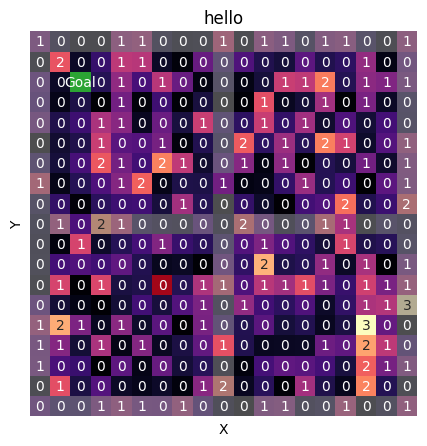

In [20]:
from plot_interactive import plot_env_heatmap

context_info = env.get_wrapper_attr('context_info')(0)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
plot_env_heatmap(mat, context_info, 'hello', 'hello')